In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.preprocessing import OneHotEncoder

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", path)

name = "mushrooms.csv"
file_path = os.path.join(path,name)
print(file_path)
df = pd.read_csv(file_path)





/home/samuele/miniforge3/envs/archi/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/samuele/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1
/home/samuele/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1/mushrooms.csv


In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
feature_cols = df.columns[1:]
feature_cols

target_col = ["class"]
target_col

['class']

In [5]:
#prendo X per le features e Y per il target

X = df[feature_cols]
X

Y = df[target_col]
Y

,class
0,p
1,e
2,e
3,p
4,e
...,...
8119,e
8120,e
8121,e
8122,p


In [6]:
df.head()



,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## Visualizzazione correlazioni feature class

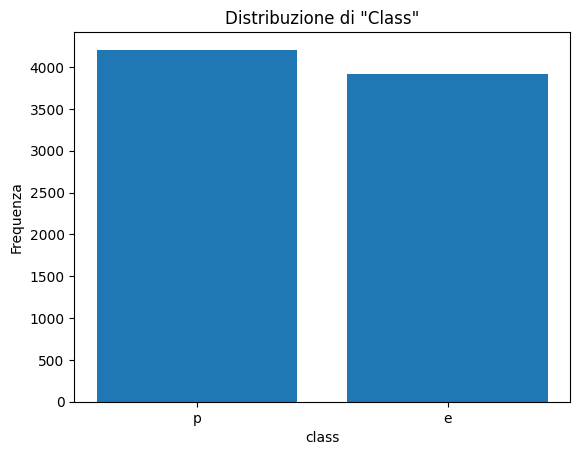

In [7]:
plt.bar(df["class"].unique(), df["class"].value_counts())
plt.xlabel("class")
plt.ylabel("Frequenza")
plt.title("Distribuzione di \"Class\"")
plt.xticks([0, 1])
plt.show()

In [8]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=['class'])
y = df['class']

mi = mutual_info_classif(X, y, discrete_features=True)

mi_series = pd.Series(mi, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

In [9]:
mi_series

odor                        0.628043
spore-print-color           0.333199
gill-color                  0.289027
ring-type                   0.220436
stalk-surface-above-ring    0.197357
stalk-surface-below-ring    0.188463
stalk-color-above-ring      0.175952
stalk-color-below-ring      0.167337
gill-size                   0.159531
population                  0.139987
bruises                     0.133347
habitat                     0.108709
stalk-root                  0.093448
gill-spacing                0.069927
cap-shape                   0.033823
ring-number                 0.026653
cap-color                   0.024987
cap-surface                 0.019817
veil-color                  0.016509
gill-attachment             0.009818
stalk-shape                 0.005210
veil-type                   0.000000
dtype: float64

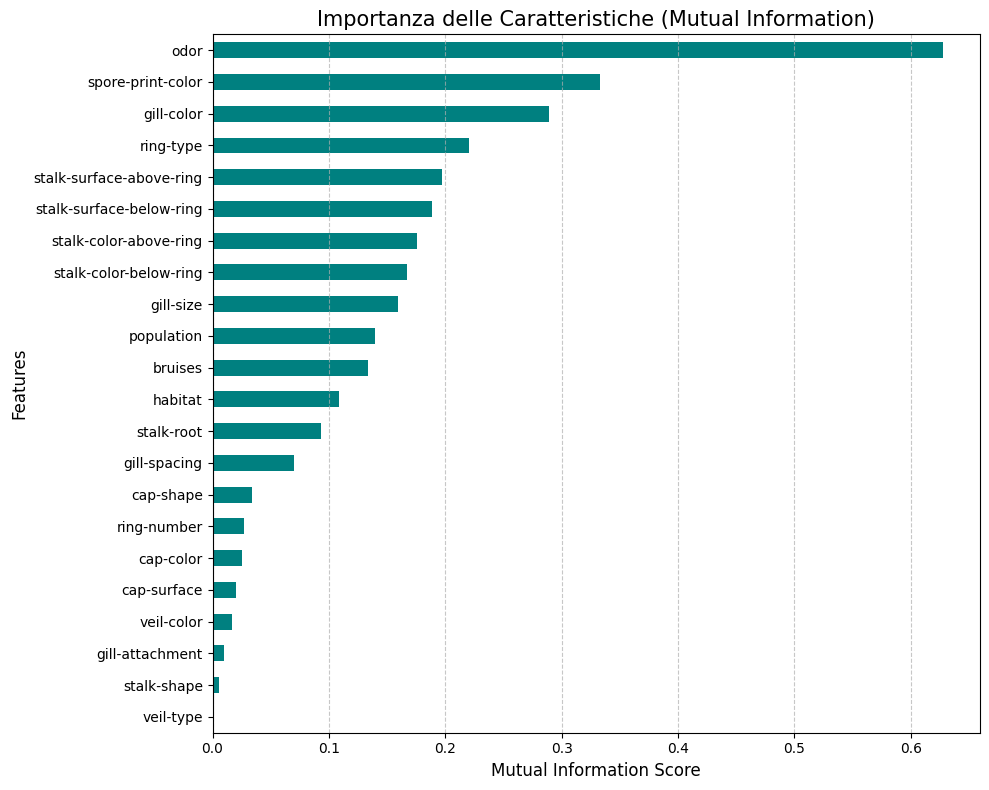

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assicurati che la serie sia ordinata (dal valore più basso al più alto per il plot orizzontale)
mi_series_sorted = mi_series.sort_values(ascending=True)

# Creazione del grafico
plt.figure(figsize=(10, 8))
mi_series_sorted.plot(kind='barh', color='teal')

# Aggiunta di etichette e titolo
plt.title('Importanza delle Caratteristiche (Mutual Information)', fontsize=15)
plt.xlabel('Mutual Information Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Correlazione features-features

In [11]:
from sklearn.preprocessing import LabelEncoder

# 1. Creiamo una copia per non sporcare il DataFrame originale
df_encoded = df.copy()

# 2. Inizializziamo l'encoder
le = LabelEncoder()

# 3. Trasformiamo ogni colonna da testo a numeri
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])



In [12]:
def mi_matrix(df):
    cols = df.columns
    out = pd.DataFrame(index=cols, columns=cols)

    for c in cols:
        mi = mutual_info_classif(df, df[c], discrete_features=True)
        out[c] = mi

    return out.astype(float)

mi_matrix=mi_matrix(df_encoded)

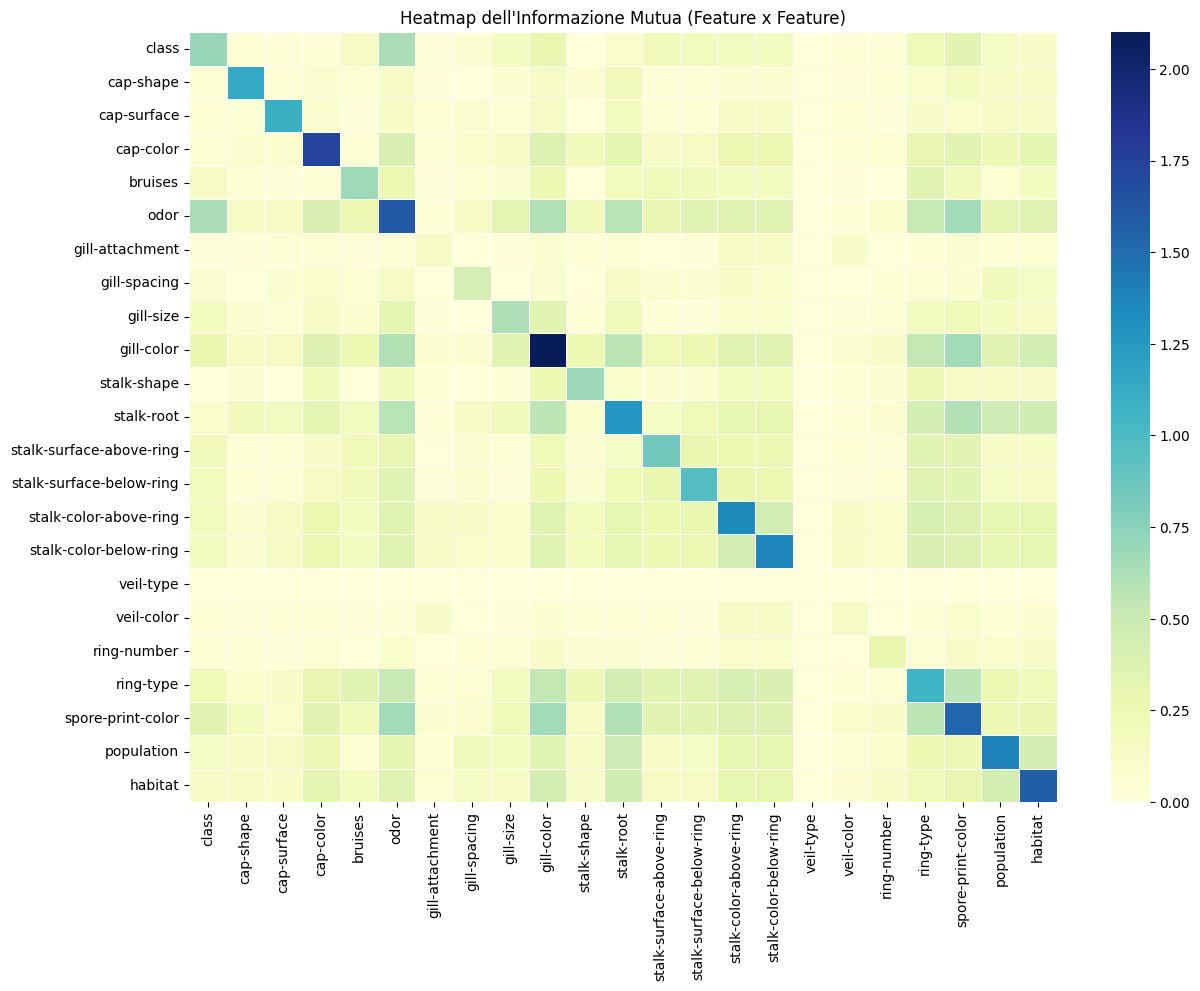

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(mi_matrix, annot=False, cmap='YlGnBu', linewidths=0.5)
plt.title("Heatmap dell'Informazione Mutua (Feature x Feature)")
plt.show()

## Addestramento, creazione training e test set

In [14]:
encoder = OneHotEncoder(sparse_output = False)

encoded_data = encoder.fit_transform(df[feature_cols])

X = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(feature_cols))

X

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8120,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8121,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8122,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [15]:

#0 → p (velenoso) e 1 → e (edible)



Y = df["class"].map({'p': 0, 'e': 1})


Y

0       0
1       1
2       1
3       0
4       1
       ..
8119    1
8120    1
8121    1
8122    0
8123    1
Name: class, Length: 8124, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X ,Y, test_size=0.3, random_state=42)

In [17]:
X_train

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
5921,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1073,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3710,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
144,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5469,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5390,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
860,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7603,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

### Inferenza

In [19]:
from sklearn.metrics import confusion_matrix

y_pred = prunedModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[1180    1]
 [   0 1257]]

Accuracy: 0.9995898277276456


In [20]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


## Modificare Training set per aggiungere rumore 

In [21]:
type(y_train)

print(y_train[5])

1


In [ ]:
import numpy as np
import pandas as pd
import random

def corrupt_rows(df, cols, frac=0.1, noise_level=0.2, random_state=None):
    rng = np.random.default_rng(random_state)
    df_corrupted = df.copy()
    
    n_rows = len(df)
    n_corrupt = int(frac * n_rows)
    
    idx = rng.choice(df.index, size=n_corrupt, replace=False)
    
    for col in cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            std = df[col].std()
            noise = rng.normal(0, noise_level * std, size=n_corrupt)
            df_corrupted.loc[idx, col] += noise
        
        else:
            values = df[col].dropna().unique()
            df_corrupted.loc[idx, col] = rng.choice(values, size=n_corrupt)
    
    return df_corrupted




def corrupt_rows_cat(df, col, frac=0.1, random_state=None):
    #conto il numero di colonne che devo rovinare

    
    corrupt_df = df.copy()

    if random_state != None: random_state = None

    #recupero i valori univoci
    unique_values = corrupt_df[col].unique()

    # Controllo di sicurezza: se ho un solo valore possibile, non posso fare la sostituzione
    if len(unique_values) <= 1:
        print(f"Attenzione: la colonna '{col}' ha un solo valore unico. Nessuna modifica applicata.")
        return corrupt_df
    
    n_rows_to_corrupt = int(frac * len(corrupt_df[col]))

    indices_to_corrupt = np.random.choice(corrupt_df.index, size=n_rows_to_corrupt, replace=False)

    for idx in indices_to_corrupt:
        current_value = corrupt_df.at[idx, col]
        pool_of_new_value = unique_values[unique_values != current_value]
        corrupt_df.at[idx, col] = np.random.choice(pool_of_new_value)
    return corrupt_df

    #scelgo righe a caso
    #per scegliere righe a caso vado a indici:
        #creo un vettore degli indici (total_rows) lungo quando il df
        #faccio un ciclo lungo n_rows_to_corrupt
        #a ogni iterazione prendo una riga scelta a caso da total_rows e la metto nel vettore "rows_to_ruin"
        #elimino quella riga dal vettore total_row

    



def comparedf_col(df1, df2, col):
    sum = 0
    for i in range(0, len(df1)):
            if df1.at[i,col] != df2.at[i,col]:
                sum +=1
    return sum

def comparedf(df1, df2):

    cols = df1.columns
    for col in cols:
        temp = comparedf_col(df1, df2, col)
        print(col,  temp )

df_corrupted = corrupt_rows_cat(df, "odor")
print(comparedf(df, df_corrupted))


        



TypeError: can only concatenate str (not "int") to str

In [30]:
df["odor"].unique()
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')

In [ ]:
unique_values = df["odor"].unique()

unique_values2 = unique_values[unique_values!='p']
unique_values2 = unique_values[unique_values!= 'a']
unique_values2

<StringArray>
['p', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 8, dtype: str